# 迁移学习

本 notebook 比较五种面向目标域小样本负荷预测的建模与迁移策略。策略命名与论文大纲保持一致，结果表中只保留中文策略名；英文全称仅在方法说明中用于对应学术概念。基础预测模型固定采用 LSTM 提取时序表征，并在输出映射前使用 LeakyReLU 激活函数，不再设置是否启用激活函数的实验开关。

## 迁移策略

1. **源域直测（Source-only）**：仅在源域建筑样本上训练 LSTM 模型，不使用目标域训练样本进行参数更新，直接在目标域测试集上评估，用于衡量源域模型的直接跨域泛化能力。
2. **目标域训练（Target-only）**：不引入源域预训练权重，仅使用目标域训练集从随机初始化开始训练模型，作为评价迁移收益的主参照策略。
3. **全层微调（Full fine-tuning）**：以源域预训练模型作为初始化，在目标域训练集上更新 LSTM 表征层和输出回归层的全部可训练参数，考察源域时序知识经目标域适配后的预测效果。
4. **固定时序表征微调（Fixed temporal representation fine-tuning）**：加载源域预训练权重后固定 LSTM 时序表征层，仅更新输出回归层参数，用于检验源域时序表征在目标建筑中的可迁移性。
5. **固定特征回归（Fixed-feature regression）**：将源域预训练 LSTM 作为固定特征提取器，并重新训练目标域回归映射层，用于分析迁移特征与目标域负荷输出之间的适配程度。


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
from scipy import stats
import joblib

# 从 src 模块导入共享配置和函数
from src import (
    # preprocessing
    load_data,
    create_sequences,
    # models
    LSTMPredictor,
    FeatureExtractorRegressor,
    # training
    set_seed,
    evaluate,
    LoadDataset,
    EarlyStopping,
    run_epoch,
    predict,
    # visualization
    setup_plot_style,
    plot_training_history,
    plot_multiseed_prediction_curves,
    # config
    BASE_DIR,
    MODEL_DIR,
    SCALER_DIR,
    FIGURES_DIR,
    TARGET_COL,
    TIME_COL,
    SEED,
)

# 超参数配置
LOOKBACK = 24   # 输入窗口长度（小时）
HORIZON = 1     # 预测步长（小时）
BATCH_SIZE = 72
EPOCHS = 100
LSTM_PARAM_GRID = {
    'hidden_size': [64, 128, 256],
    'num_layers': [1, 2],
}
GRID_SEARCH_SEED = SEED
HIDDEN_SIZE = None
NUM_LAYERS = None
REPEAT_SEEDS = [7, 21, 84, 2024]
METRIC_COLS = ['MAE', 'RMSE', 'CV-RMSE', 'MAPE', 'R2']

set_seed(SEED)
criterion = nn.L1Loss()

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

setup_plot_style()
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

## 数据准备

In [2]:
# 数据路径
SOURCE_TRAIN_PATH = BASE_DIR / 'source_train_std.csv'  # 源域全量数据
TARGET_TRAIN_PATH = BASE_DIR / 'target_train_std.csv'
TARGET_VAL_PATH = BASE_DIR / 'target_val_std.csv'
TARGET_TEST_PATH = BASE_DIR / 'target_test_std.csv'

# 读取源域数据（全量数据）
source_full_df = load_data(SOURCE_TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

# 加载目标域 scaler
target_scaler = joblib.load(SCALER_DIR / 'target_load_scaler.joblib')

# 从源域全量数据中划分部分作为验证集（用于早停）
source_val_ratio = 0.2
source_n = len(source_full_df)
source_val_end = int(source_n * source_val_ratio)

source_train_df = source_full_df.iloc[:-source_val_end].reset_index(drop=True)
source_val_df = source_full_df.iloc[-source_val_end:].reset_index(drop=True)

# 读取目标域数据
target_train_df = load_data(TARGET_TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
target_val_df = load_data(TARGET_VAL_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
target_test_df = load_data(TARGET_TEST_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

# 确定特征列（除时间戳外）
FEATURE_COLS = [c for c in source_train_df.columns if c != TIME_COL]
input_size = len(FEATURE_COLS)

# 构造序列
X_source_train, y_source_train = create_sequences(source_train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)
X_source_val, y_source_val = create_sequences(source_val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)

X_target_train, y_target_train = create_sequences(target_train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)
X_target_val, y_target_val = create_sequences(target_val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)
X_target_test, y_target_test = create_sequences(target_test_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)

# 数据流：DataFrame -> create_sequences 生成 ndarray -> LoadDataset 适配 PyTorch
torch_datasets = {
    'source_train': LoadDataset(X_source_train, y_source_train),
    'source_val': LoadDataset(X_source_val, y_source_val),
    'target_train': LoadDataset(X_target_train, y_target_train),
    'target_val': LoadDataset(X_target_val, y_target_val),
    'target_test': LoadDataset(X_target_test, y_target_test),
}

print(f"　源域训练序列: {X_source_train.shape}")
print(f"　源域验证序列: {X_source_val.shape}")
print(f"\n目标域训练序列: {X_target_train.shape}")
print(f"目标域验证序列: {X_target_val.shape}")
print(f"目标域测试序列: {X_target_test.shape}")

　源域训练序列: (6920, 24, 45)
　源域验证序列: (1732, 24, 45)

目标域训练序列: (1497, 24, 45)
目标域验证序列: (307, 24, 45)
目标域测试序列: (308, 24, 45)


## LSTM结构参数网格搜索

为降低隐藏层单元数和网络层数的主观性，先在目标域训练集和目标域验证集上对 `hidden_size=[64, 128, 256]` 与 `num_layers=[1, 2]` 做网格搜索。每组候选结构都使用相同训练流程和早停机制，最终以验证集 MAE 最小作为目标函数选择最优结构；测试集不参与参数选择。


In [3]:
def fit_model(model, train_loader, val_loader, optimizer, lr_scheduler, early_stopping) -> tuple:
    train_losses = []
    val_losses = []
    for epoch in range(EPOCHS):
        train_loss = run_epoch(model, train_loader, criterion, device, optimizer)
        val_loss = run_epoch(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        lr_scheduler.step(val_loss)

        if early_stopping(val_loss, model, epoch):
            break

    early_stopping.restore(model)
    return train_losses, val_losses, early_stopping.get_best_info()


def train_lstm_grid_candidate(hidden_size: int, num_layers: int, seed: int = GRID_SEARCH_SEED) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        horizon=HORIZON,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_val_pred = predict(model, target_val_loader, device)
    val_metrics = evaluate(y_target_val, y_val_pred, target_scaler)

    result = {
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'best_epoch': best_info['best_epoch'],
        'best_val_loss': best_info['best_loss'],
        'epochs': len(train_losses),
    }
    result.update({f'val_{metric}': value for metric, value in val_metrics.items()})
    return result


grid_search_rows = []
for hidden_size in LSTM_PARAM_GRID['hidden_size']:
    for num_layers in LSTM_PARAM_GRID['num_layers']:
        grid_result = train_lstm_grid_candidate(hidden_size, num_layers)
        grid_search_rows.append(grid_result)
        print(
            f"grid hidden_size={hidden_size}, num_layers={num_layers}: "
            f"val_MAE={grid_result['val_MAE']:.4f}, best_epoch={grid_result['best_epoch']}"
        )

lstm_grid_search_df = (
    pd.DataFrame(grid_search_rows)
    .sort_values(['val_MAE', 'best_val_loss', 'num_layers', 'hidden_size'])
    .reset_index(drop=True)
)
lstm_grid_search_df.to_csv(
    BASE_DIR / 'transfer_learning_lstm_grid_search_results.csv',
    index=False,
    encoding='utf-8-sig',
)
best_lstm_params = lstm_grid_search_df.iloc[0]
HIDDEN_SIZE = int(best_lstm_params['hidden_size'])
NUM_LAYERS = int(best_lstm_params['num_layers'])

print('\nLSTM结构参数网格搜索结果：')
print(lstm_grid_search_df[['hidden_size', 'num_layers', 'best_epoch', 'best_val_loss', 'val_MAE']].to_string(index=False))
print(f"\n选择最优结构: hidden_size={HIDDEN_SIZE}, num_layers={NUM_LAYERS}")

grid hidden_size=64, num_layers=1: val_MAE=11.5384, best_epoch=19
grid hidden_size=64, num_layers=2: val_MAE=11.2367, best_epoch=19
grid hidden_size=128, num_layers=1: val_MAE=9.7688, best_epoch=14
grid hidden_size=128, num_layers=2: val_MAE=9.5902, best_epoch=15
grid hidden_size=256, num_layers=1: val_MAE=9.0166, best_epoch=16
grid hidden_size=256, num_layers=2: val_MAE=8.0522, best_epoch=19

LSTM结构参数网格搜索结果：
 hidden_size  num_layers  best_epoch  best_val_loss   val_MAE
         256           2          19       0.281130  8.052185
         256           1          16       0.314800  9.016580
         128           2          15       0.334826  9.590153
         128           1          14       0.341063  9.768816
          64           2          19       0.392313 11.236703
          64           1          19       0.402846 11.538401

选择最优结构: hidden_size=256, num_layers=2


## 训练函数与多 seed 实验

下方按相同随机种子依次执行源域直测（Source-only）、目标域训练（Target-only）以及三种迁移学习策略：全层微调（Full fine-tuning）、固定时序表征微调（Fixed temporal representation fine-tuning）和固定特征回归（Fixed-feature regression）。所有策略统一使用上方验证集选择得到的 LSTM 结构，并固定采用 LeakyReLU 激活函数，以保证后续比较聚焦于迁移机制差异，而不是模型容量或非线性映射设置差异。

各训练函数内部自行构造所需 DataLoader、EarlyStopping 和学习率调度器。每个 seed 运行时记录指标、预测序列和 loss 序列；所有 seed 结束后按策略保存多 seed 汇总预测图，loss 图直接使用配置中的 `SEED`，并调用 `plot_training_history()` 按阶段保存单次训练曲线。统计汇总时，`SEED` 与 `REPEAT_SEEDS` 中的 seed 一起纳入多 seed 平均和置信区间。

- `run_source_only()`：源域直测（Source-only）
- `run_target_only()`：目标域训练（Target-only）
- `run_full_fine_tuning()`：全层微调（Full fine-tuning）
- `run_fixed_temporal_representation_fine_tuning()`：固定时序表征微调（Fixed temporal representation fine-tuning）
- `run_fixed_feature_regression()`：固定特征回归（Fixed-feature regression）


In [4]:
prediction_records = []
loss_records = []

PREDICTION_STRATEGIES = [
    '源域直测',
    '目标域训练',
    '全层微调',
    '固定时序表征微调',
    '固定特征回归',
]
LOSS_STAGES = [
    '源域预训练',
    '目标域训练',
    '全层微调',
    '固定时序表征微调',
    '固定特征回归',
]

def inverse_target_load(values: np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape).ravel()


def record_prediction_curve(seed: int, strategy: str, y_true_std: np.ndarray, y_pred_std: np.ndarray) -> None:
    prediction_records.append({
        'seed': seed,
        '策略': strategy,
        'y_true': inverse_target_load(y_true_std),
        'y_pred': inverse_target_load(y_pred_std),
    })


def record_loss_curve(seed: int, stage: str, train_losses: list, val_losses: list) -> None:
    loss_records.append({
        'seed': seed,
        '阶段': stage,
        'train_losses': np.asarray(train_losses, dtype=float),
        'val_losses': np.asarray(val_losses, dtype=float),
    })


def make_result(seed: int, strategy: str, metrics: dict, best_info: dict = None, train_losses: list = None) -> dict:
    return {
        'seed': seed,
        '策略': strategy,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        **metrics,
        'best_epoch': np.nan if best_info is None else best_info['best_epoch'],
        'best_val_loss': np.nan if best_info is None else best_info['best_loss'],
        'epochs': 0 if train_losses is None else len(train_losses),
    }


def train_source(seed: int) -> dict:
    set_seed(seed)
    source_train_loader = DataLoader(
        torch_datasets['source_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    source_val_loader = DataLoader(torch_datasets['source_val'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=HORIZON).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, source_train_loader, source_val_loader, optimizer, lr_scheduler, early_stopping
    )
    record_loss_curve(seed, '源域预训练', train_losses, val_losses)

    torch.save(model.state_dict(), MODEL_DIR / 'pretrained_source.pt')
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def run_source_only(seed: int, source_state: dict) -> dict:
    set_seed(seed)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=HORIZON).to(device)
    model.load_state_dict(source_state)

    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)
    record_prediction_curve(seed, '源域直测', y_target_test, y_pred)

    return make_result(seed, '源域直测', metrics)


def run_target_only(seed: int) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=HORIZON).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)
    record_prediction_curve(seed, '目标域训练', y_target_test, y_pred)
    record_loss_curve(seed, '目标域训练', train_losses, val_losses)

    torch.save(model.state_dict(), MODEL_DIR / 'transfer_target_only.pt')
    return make_result(seed, '目标域训练', metrics, best_info, train_losses)


def run_full_fine_tuning(seed: int, source_state: dict) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=HORIZON).to(device)
    model.load_state_dict(source_state)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)
    record_prediction_curve(seed, '全层微调', y_target_test, y_pred)
    record_loss_curve(seed, '全层微调', train_losses, val_losses)

    torch.save(model.state_dict(), MODEL_DIR / 'transfer_full_fine_tuning.pt')
    return make_result(seed, '全层微调', metrics, best_info, train_losses)


def run_fixed_temporal_representation_fine_tuning(seed: int, source_state: dict) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=HORIZON).to(device)
    model.load_state_dict(source_state)

    # 固定源域预训练得到的 LSTM 时序表征，仅训练目标域输出映射。
    for name, param in model.named_parameters():
        if 'lstm' in name:
            param.requires_grad = False

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)
    record_prediction_curve(seed, '固定时序表征微调', y_target_test, y_pred)
    record_loss_curve(seed, '固定时序表征微调', train_losses, val_losses)

    torch.save(model.state_dict(), MODEL_DIR / 'transfer_fixed_temporal_representation_fine_tuning.pt')
    return make_result(seed, '固定时序表征微调', metrics, best_info, train_losses)


def run_fixed_feature_regression(seed: int, source_state: dict) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    pretrained = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=HORIZON).to(device)
    pretrained.load_state_dict(source_state)
    model = FeatureExtractorRegressor(pretrained, horizon=HORIZON).to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)
    record_prediction_curve(seed, '固定特征回归', y_target_test, y_pred)
    record_loss_curve(seed, '固定特征回归', train_losses, val_losses)

    torch.save(model.state_dict(), MODEL_DIR / 'transfer_fixed_feature_regression.pt')
    return make_result(seed, '固定特征回归', metrics, best_info, train_losses)


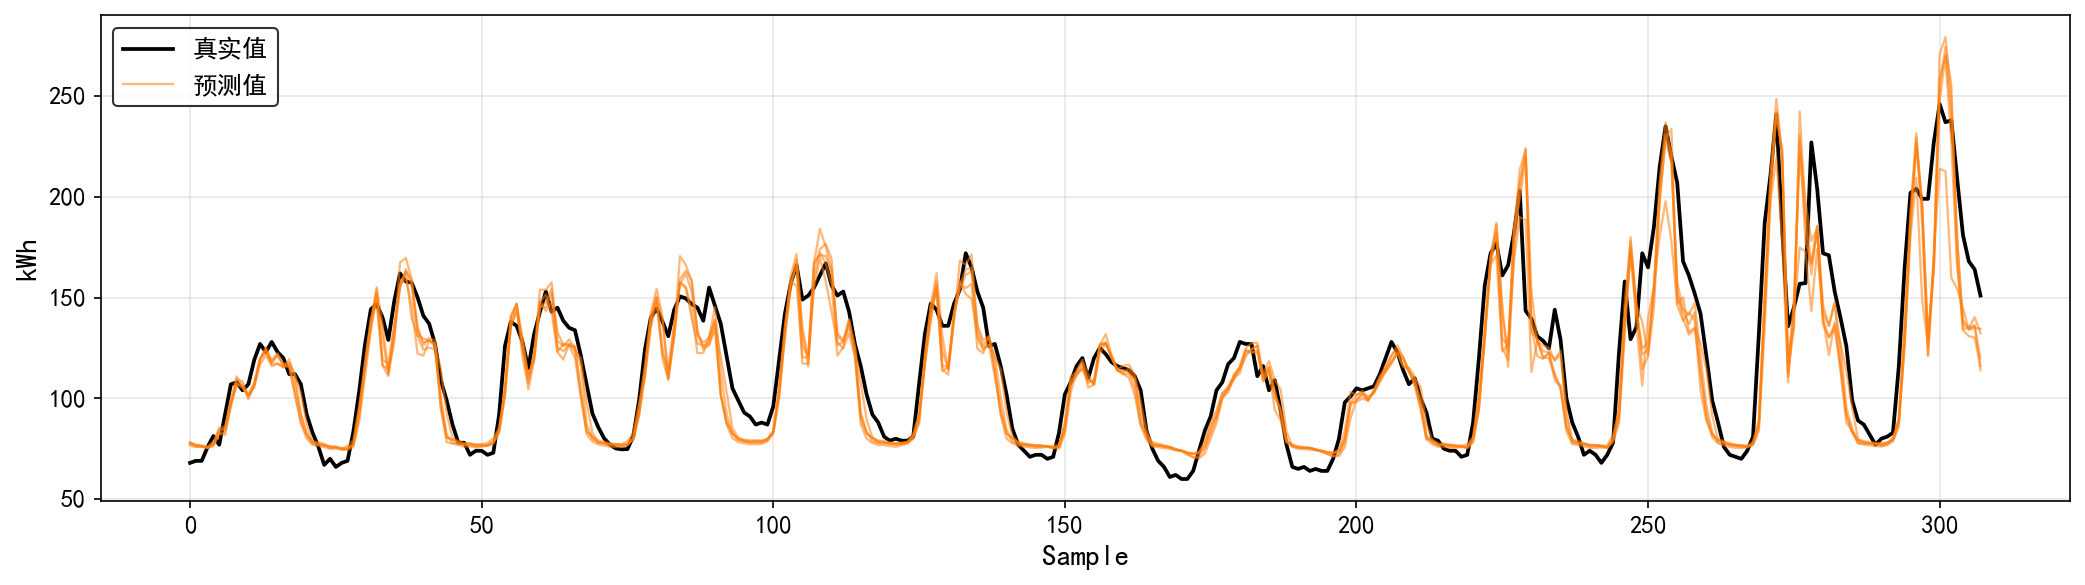

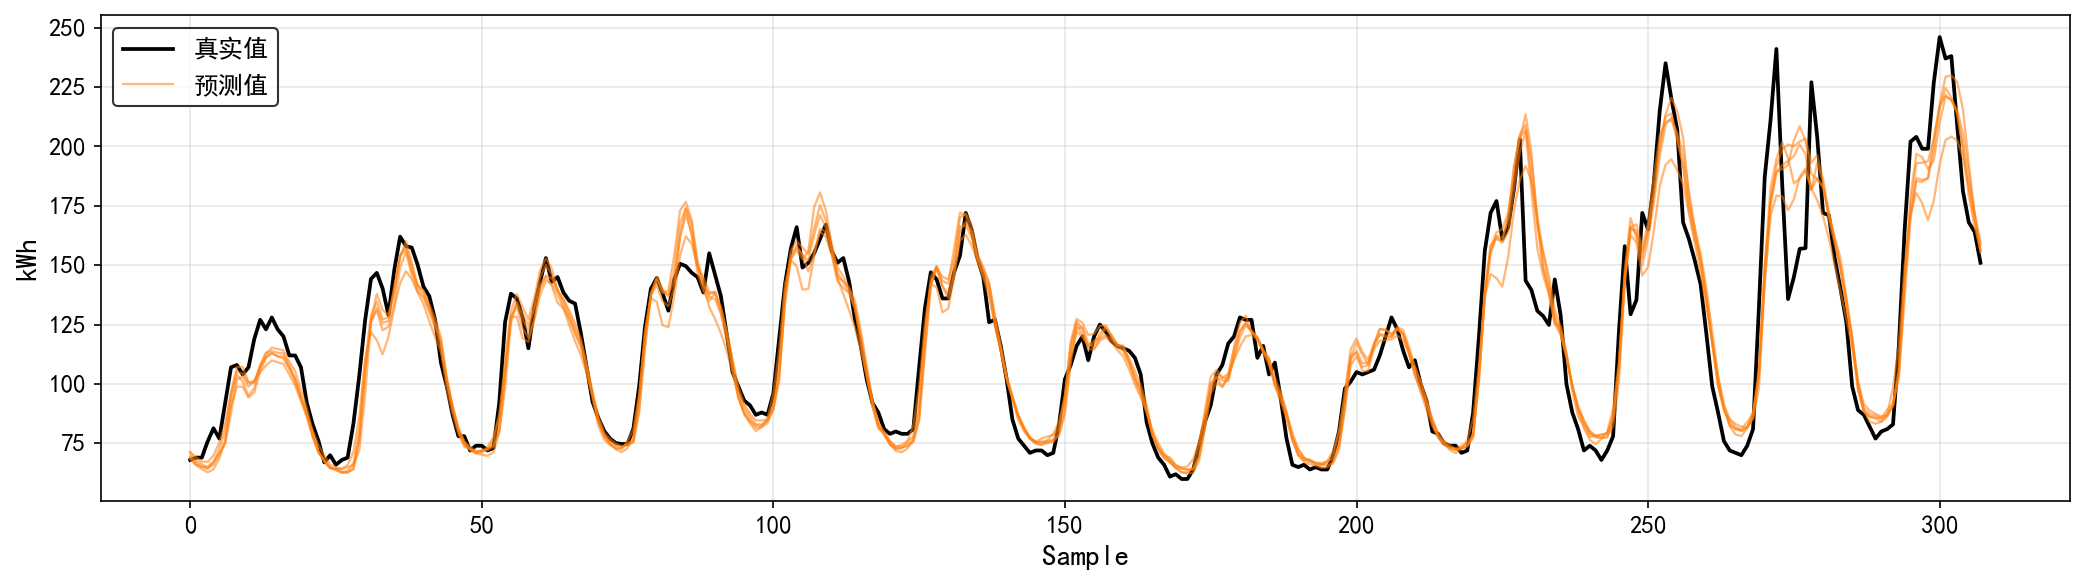

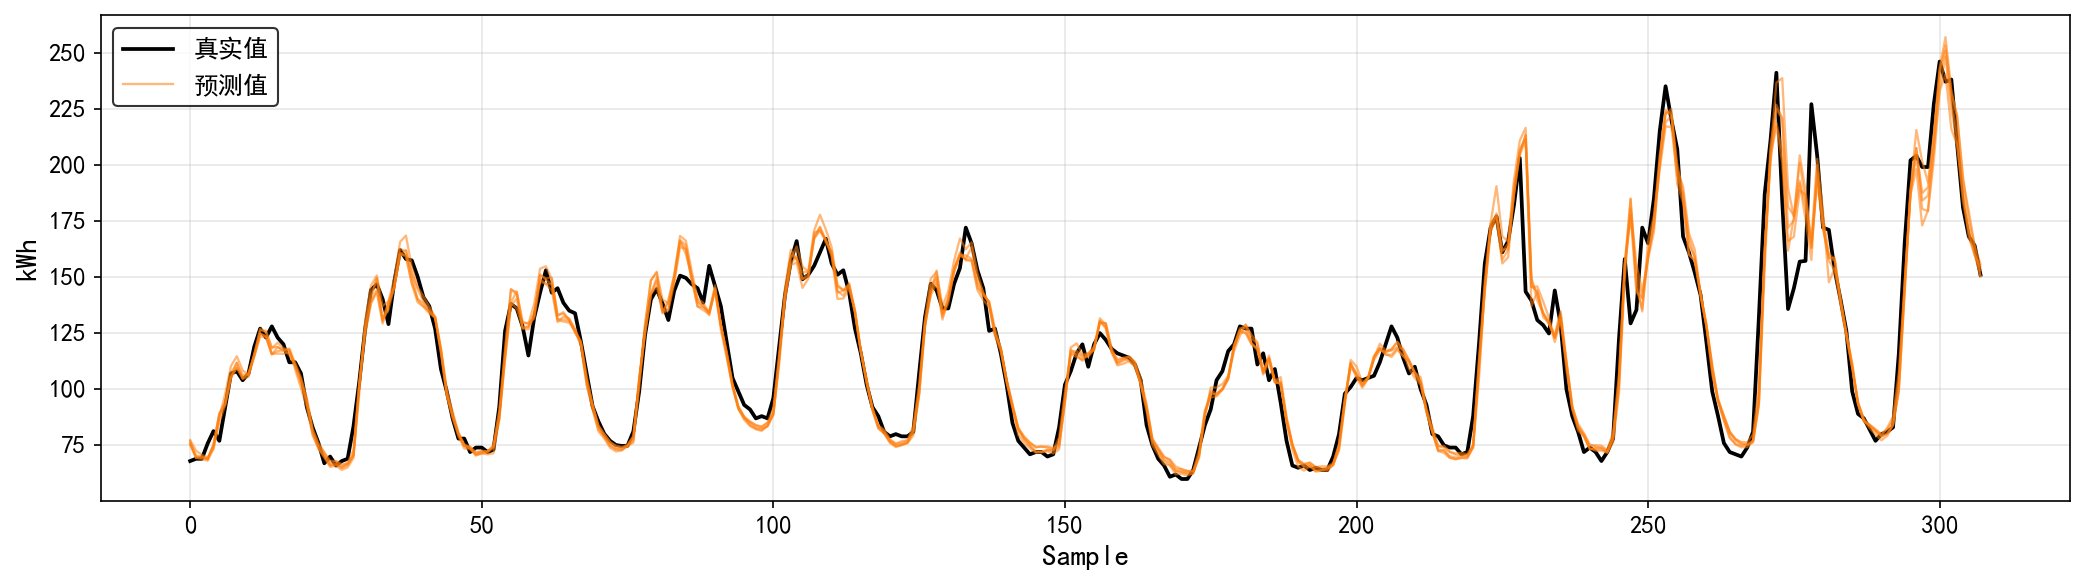

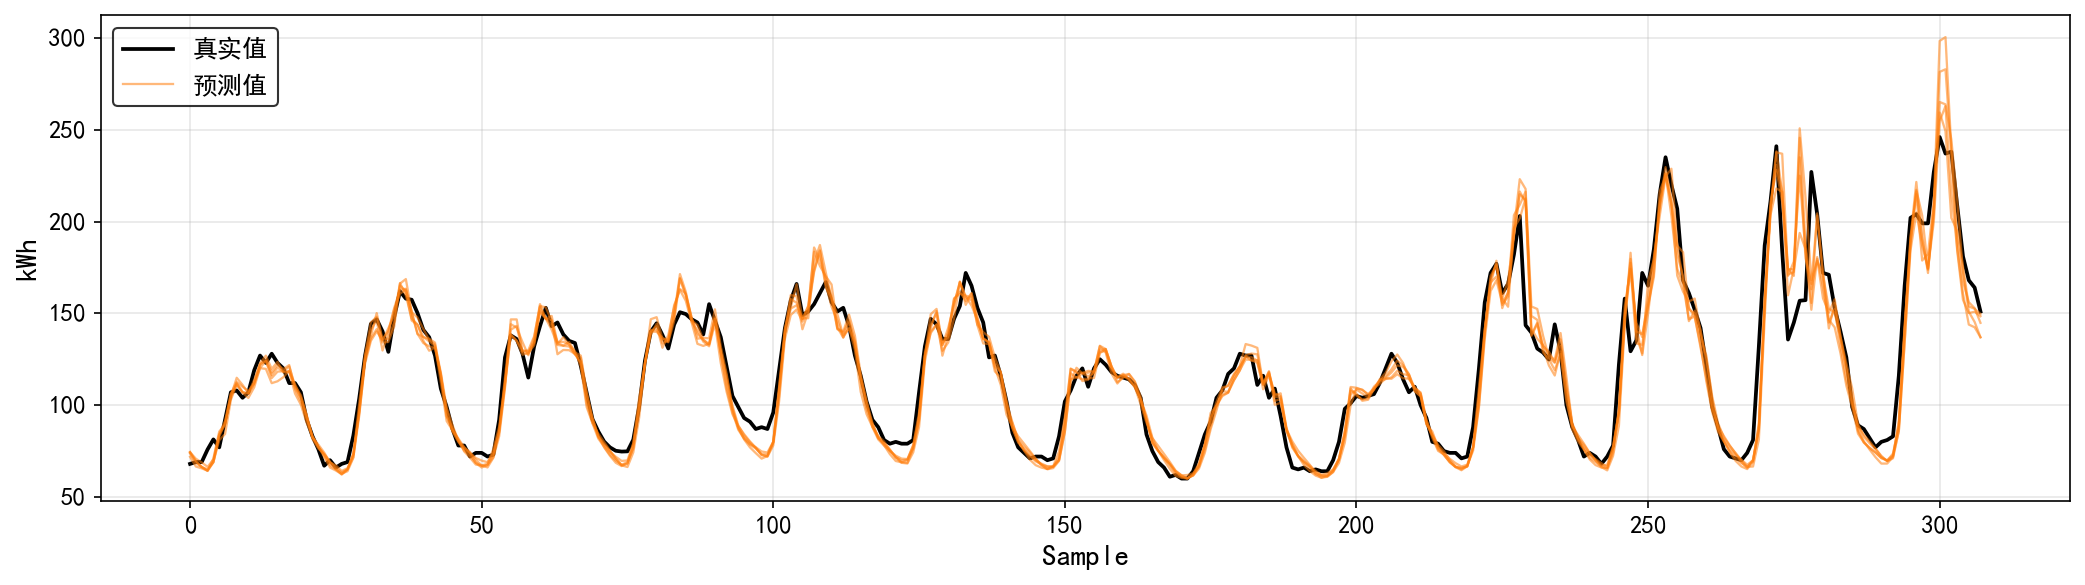

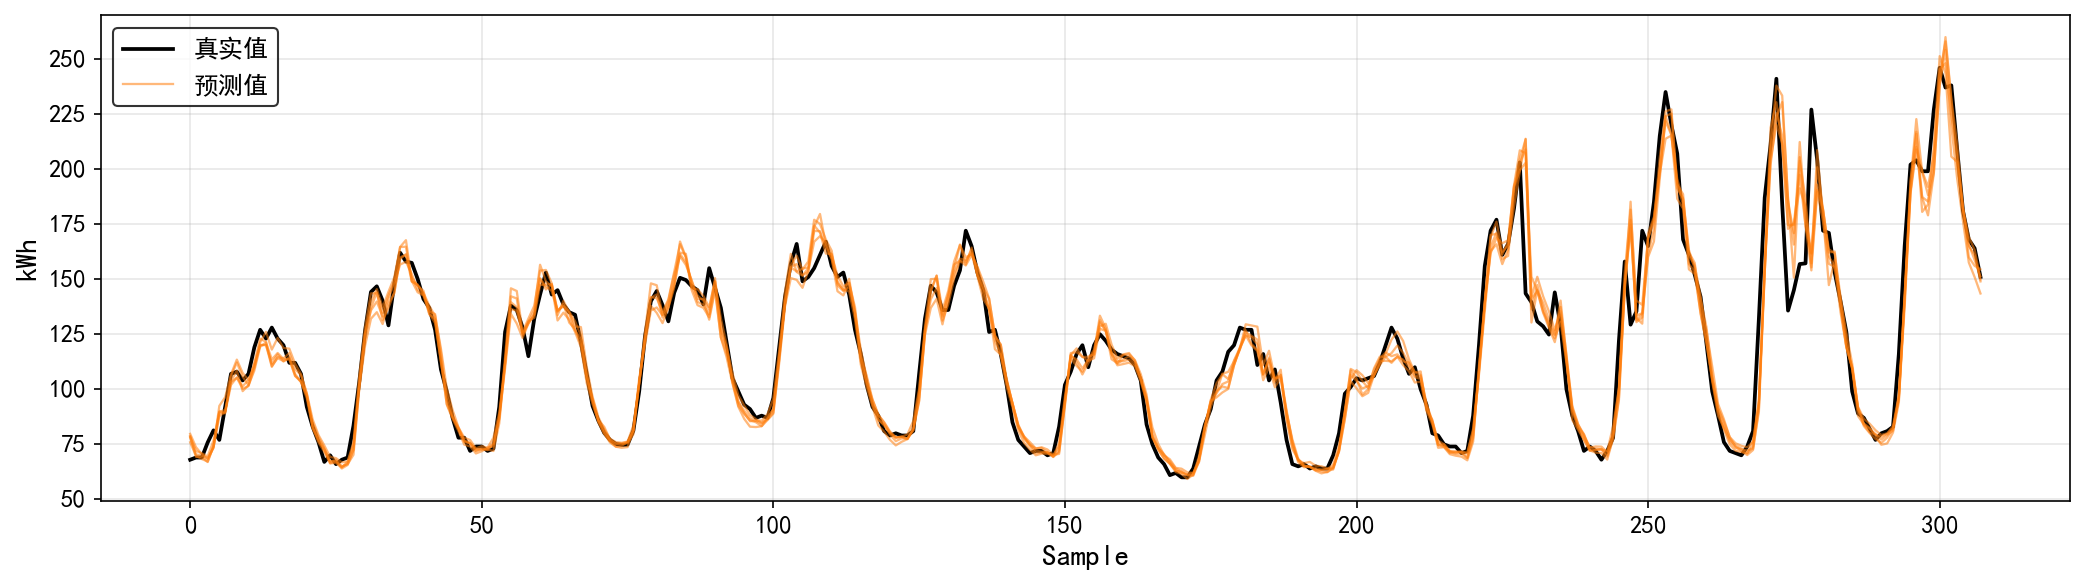

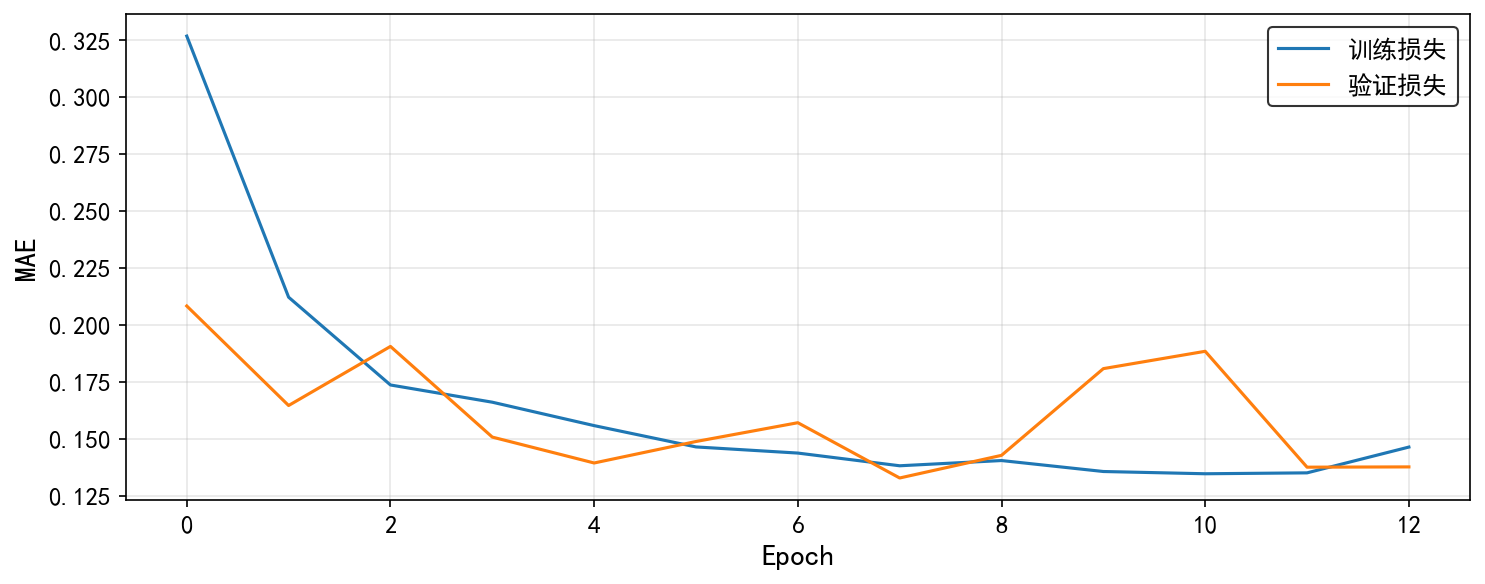

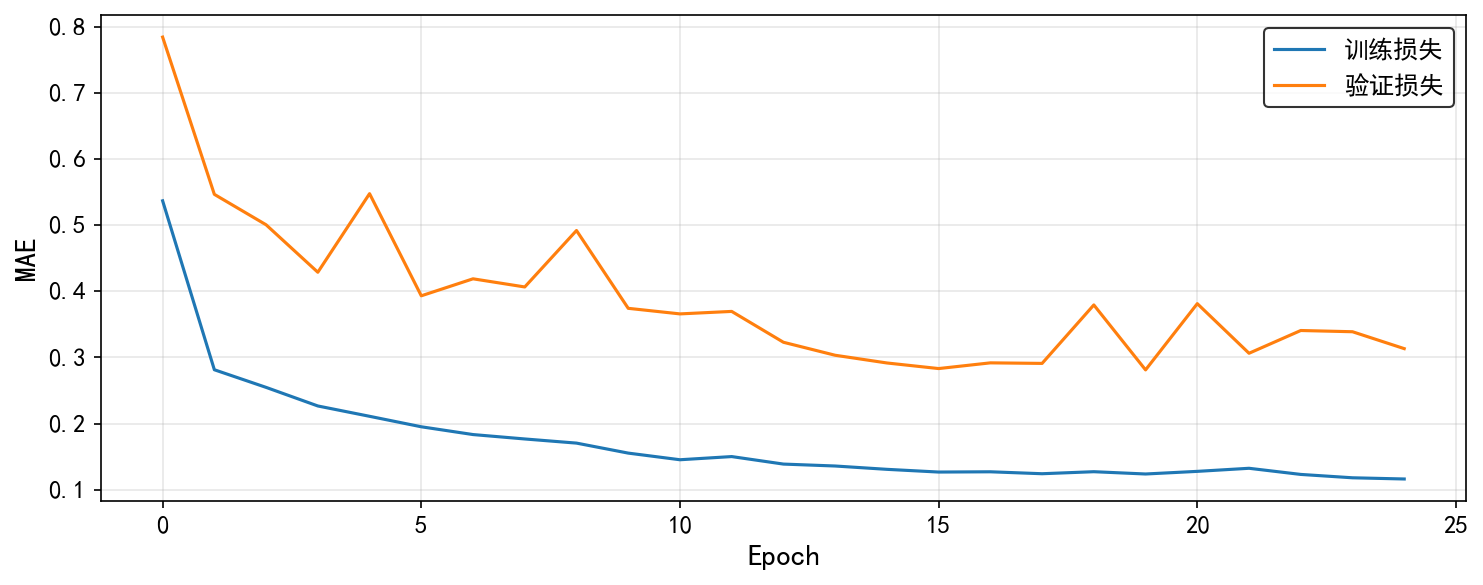

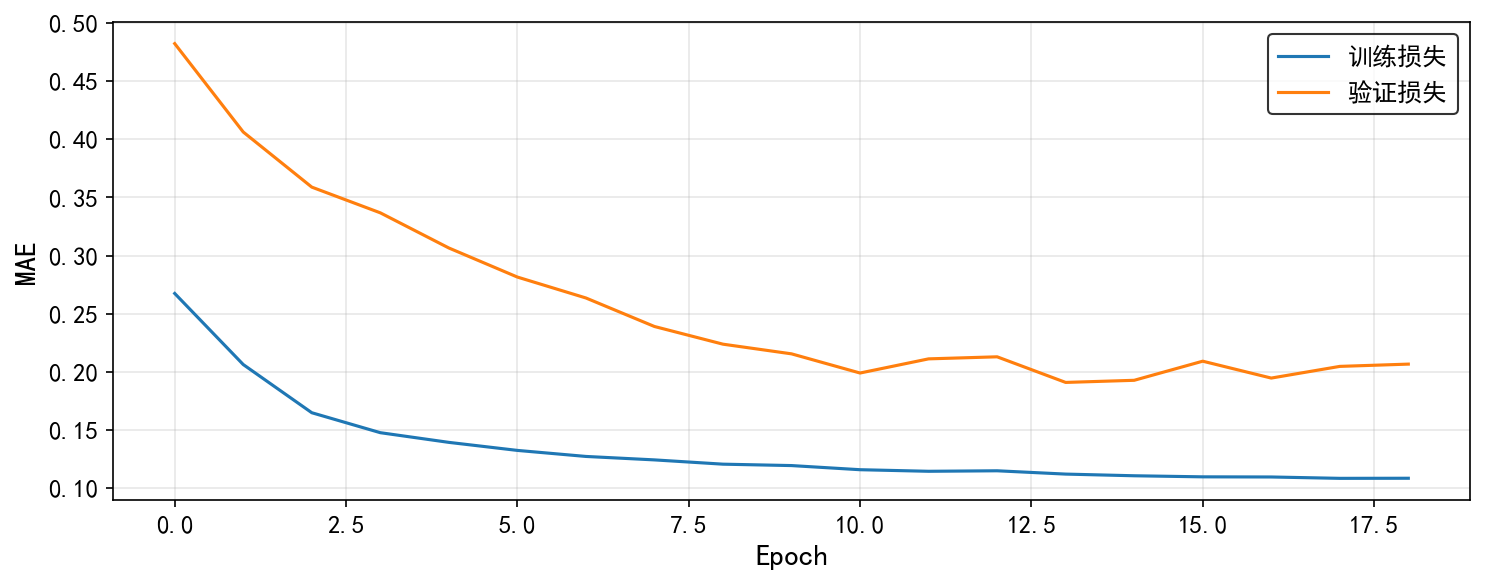

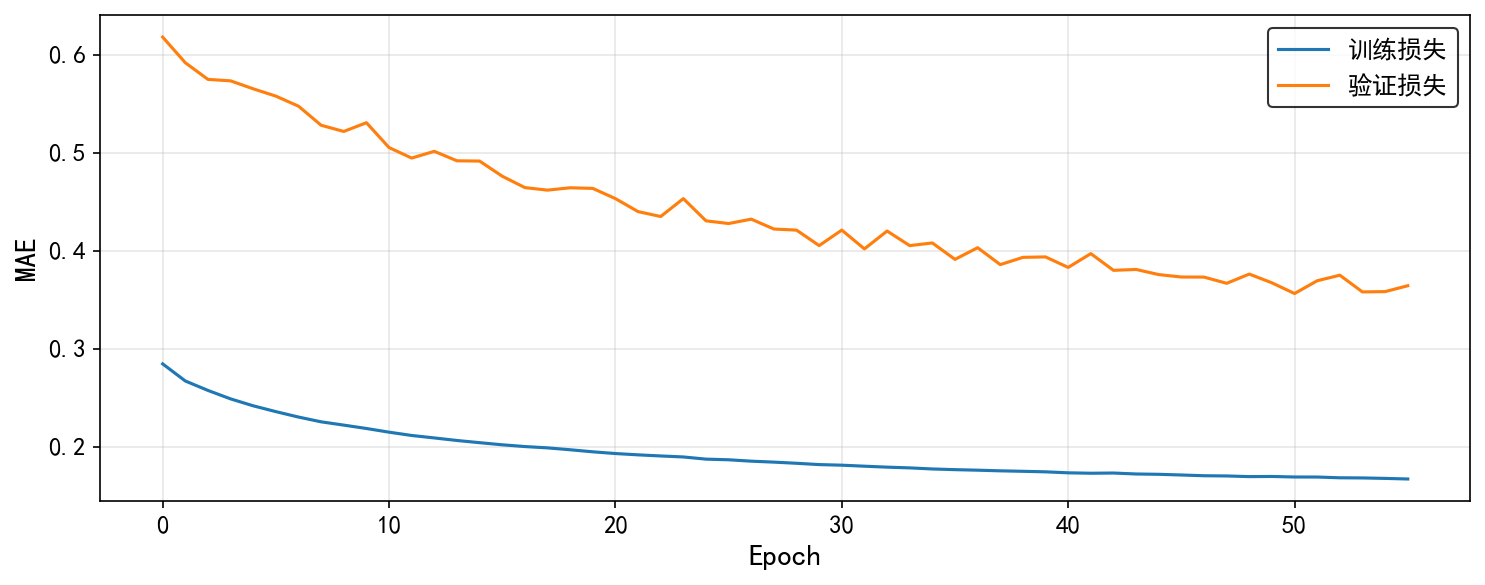

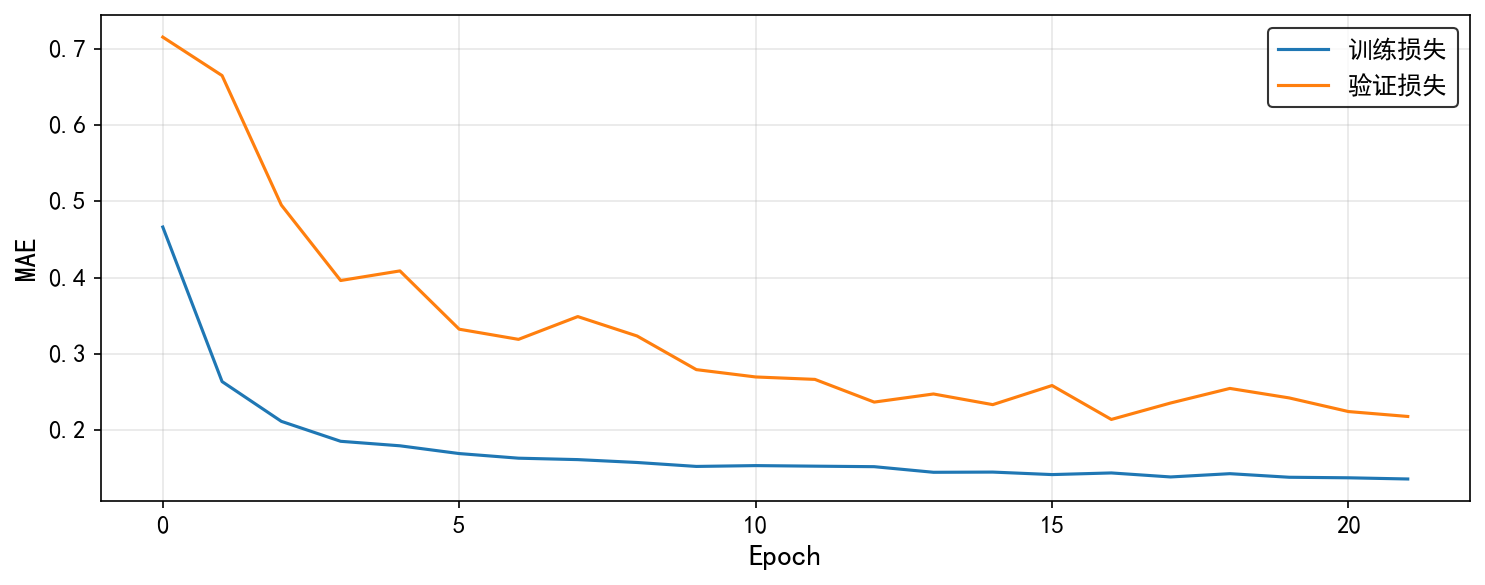

In [5]:
seed_results = []
prediction_records.clear()
loss_records.clear()

for seed in [*REPEAT_SEEDS, SEED]:
    source_state = train_source(seed)
    results = [
        run_source_only(seed, source_state),
        run_target_only(seed),
        run_full_fine_tuning(seed, source_state),
        run_fixed_temporal_representation_fine_tuning(seed, source_state),
        run_fixed_feature_regression(seed, source_state),
    ]
    seed_results.extend(results)

plot_multiseed_prediction_curves(prediction_records, FIGURES_DIR, PREDICTION_STRATEGIES, show=True)

for stage in LOSS_STAGES:
    stage_record = next(
        (record for record in loss_records if record['seed'] == SEED and record['阶段'] == stage),
        None,
    )
    if stage_record is None:
        continue

    plot_training_history(
        stage_record['train_losses'],
        stage_record['val_losses'],
        save_path=FIGURES_DIR / f'{stage}_损失曲线.png',
    )


## 实验结果汇总

In [6]:
def mean_ci(values, confidence: float = 0.95) -> tuple:
    arr = np.asarray(values, dtype=float)
    mean = arr.mean()
    std = arr.std(ddof=1)
    margin = stats.t.ppf((1 + confidence) / 2, len(arr) - 1) * stats.sem(arr)
    return mean, std, mean - margin, mean + margin, margin

# 每行对应一个 seed 下的一种策略，是后续统计汇总的基础明细表。
per_seed_metrics_df = pd.DataFrame(seed_results)

# 每行对应一种策略，指标列为全部 seed 的平均值，供后续可视化和论文主结果表使用。
strategy_mean_metrics_df = (
    per_seed_metrics_df.groupby('策略', sort=False)[METRIC_COLS]
    .mean()
    .reset_index()
)

# 每行对应“策略-指标”组合，保留 mean/std/95% CI，便于论文补充统计说明。
strategy_metric_stats_rows = []
for strategy, group in per_seed_metrics_df.groupby('策略', sort=False):
    for metric in METRIC_COLS:
        mean, std, ci_low, ci_high, ci_margin = mean_ci(group[metric])
        strategy_metric_stats_rows.append({
            '策略': strategy,
            '指标': metric,
            'mean': mean,
            'std': std,
            'ci95_low': ci_low,
            'ci95_high': ci_high,
            'ci95_margin': ci_margin,
        })
strategy_metric_stats_df = pd.DataFrame(strategy_metric_stats_rows)

print('多 seed 平均结果：')
print(strategy_mean_metrics_df.to_string(index=False))

# 用于结果和可视化的多 seed 均值表
strategy_mean_metrics_df.to_csv(BASE_DIR / 'transfer_learning_strategy_mean_metrics.csv', index=False, encoding='utf-8-sig')
# 逐 seed、逐策略的基础明细表
per_seed_metrics_df.to_csv(BASE_DIR / 'transfer_learning_per_seed_metrics.csv', index=False, encoding='utf-8-sig')
# 策略-指标粒度的 mean/std/95%CI 表
strategy_metric_stats_df.to_csv(BASE_DIR / 'transfer_learning_strategy_metric_stats.csv', index=False, encoding='utf-8-sig')

多 seed 平均结果：
      策略       MAE      RMSE   CV-RMSE     MAPE       R2
    源域直测 11.997673 17.593866 14.888696 9.591714 0.811712
   目标域训练  9.237530 13.638567 11.541550 7.516170 0.886852
    全层微调  6.444602 10.638171  9.002484 5.231682 0.931229
固定时序表征微调  8.145742 12.981802 10.985766 6.671669 0.897470
  固定特征回归  6.771502 11.180850  9.461722 5.435625 0.924055


## 结果分析

本 notebook 同时保留 LSTM 结构参数搜索结果、多 seed 明细、均值统计和置信区间统计结果。结果表中的 `策略` 只保留中文策略名，便于直接用于论文主表和后续可视化。

1. **LSTM结构参数搜索结果**：写入 `transfer_learning_lstm_grid_search_results.csv`，每行对应一组 `hidden_size` 与 `num_layers` 候选结构，并保存验证集 MAE、最佳验证损失和最佳 epoch。该表用于说明 LSTM 隐藏层单元数和网络层数不是主观指定，而是依据目标域验证集误差选择。测试集不参与参数选择。

2. **多 seed 平均结果**：写入 `transfer_learning_strategy_mean_metrics.csv`，每行对应一种策略，第一列仅为中文策略名，后续列为该策略在全部 seed 上的 MAE、RMSE、CV-RMSE、MAPE 和 R2 平均值，供后续可视化 notebook 和论文结果表使用。配置中的 `SEED` 只用于固定同名模型的最终保存版本，统计时与 `REPEAT_SEEDS` 中的 seed 一起纳入平均，不作为单独结论依据。

3. **多 seed 明细**：写入 `transfer_learning_per_seed_metrics.csv`，每行对应一个 seed 和一种策略，并记录该轮实验统一采用的模型结构。

4. **均值与置信区间**：写入 `transfer_learning_strategy_metric_stats.csv`，报告 mean、std 和 95% CI。该文件各字段含义如下：

   - `策略`：策略中文名称，包括源域直测、目标域训练、全层微调、固定时序表征微调和固定特征回归。
   - `指标`：评价指标名称，包括 MAE、RMSE、CV-RMSE、MAPE 和 R2。
   - `mean`：同一策略在所有 seed 上该指标的平均值，是论文定量比较的主要依据。
   - `std`：同一策略在所有 seed 上该指标的样本标准差，用于衡量随机训练带来的波动。
   - `ci95_low` / `ci95_high`：基于 t 分布计算的均值 95% 置信区间下界和上界。
   - `ci95_margin`：95% 置信区间半宽，即 `mean ± ci95_margin` 中的 margin。

5. **曲线图**：按策略分别写入 `data/figures/{策略}_预测对比.png`，每张图展示同一策略下所有 seed 的预测曲线，并以真实值曲线作为共同参照；同时按训练阶段写入 `data/figures/{阶段}_损失曲线.png`，loss 图只展示配置 `SEED` 对应的单次训练损失和验证损失曲线。预测图中不同 seed 的预测曲线使用相同颜色，图例只区分真实值/预测值；loss 图图例只区分训练损失/验证损失。

论文中建议先用 `transfer_learning_lstm_grid_search_results.csv` 说明 LSTM 结构参数选择依据，再以 `transfer_learning_strategy_mean_metrics.csv` 和 `transfer_learning_strategy_metric_stats.csv` 的多 seed 均值、标准差与置信区间作为主要结果。模型文件名保留英文描述，图表文件名使用中文策略名，便于与论文图表标题对应。
